In [ ]:

pip install tensorflow scikit-image matplotlib

Original image: (1, 64, 64, 3)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Image (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_128 (Dense)              │ (None, 128)            │     2,097,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,672 (8.07 MB)

 Trainable params: 2,116,672 (8.07 MB)

 Non-trainable params: 0 (0.00 B)


CNN TRANSFORMATION
Input: (64, 64, 3)
Conv1: (64, 64, 32)
Pool1: (32, 32, 32)
Conv2: (32, 32, 64)
Pool2: (16, 16, 64)
Flatten: (16384,)
Latent: (128,)


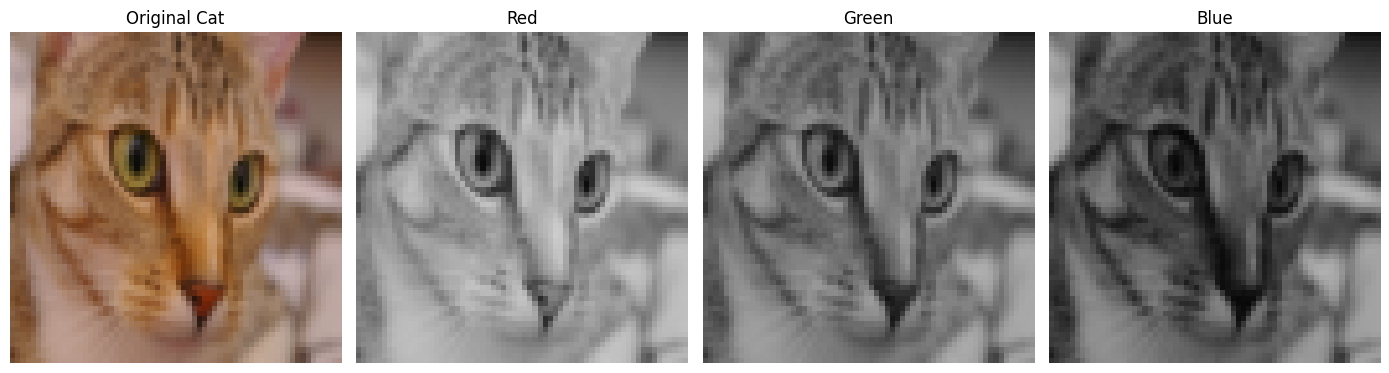

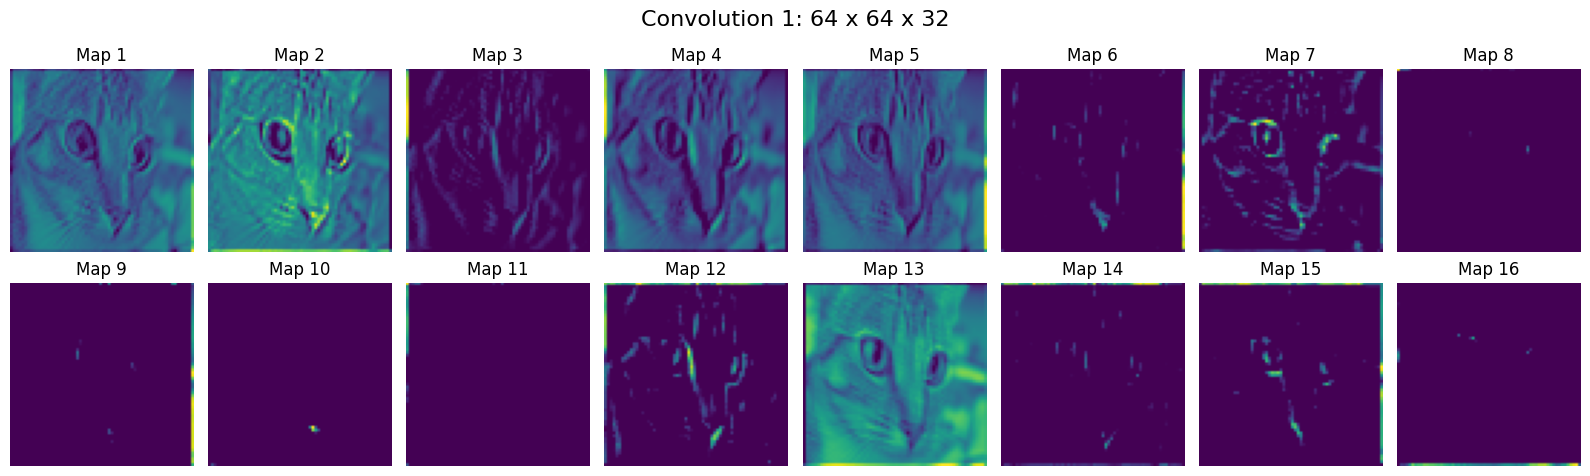

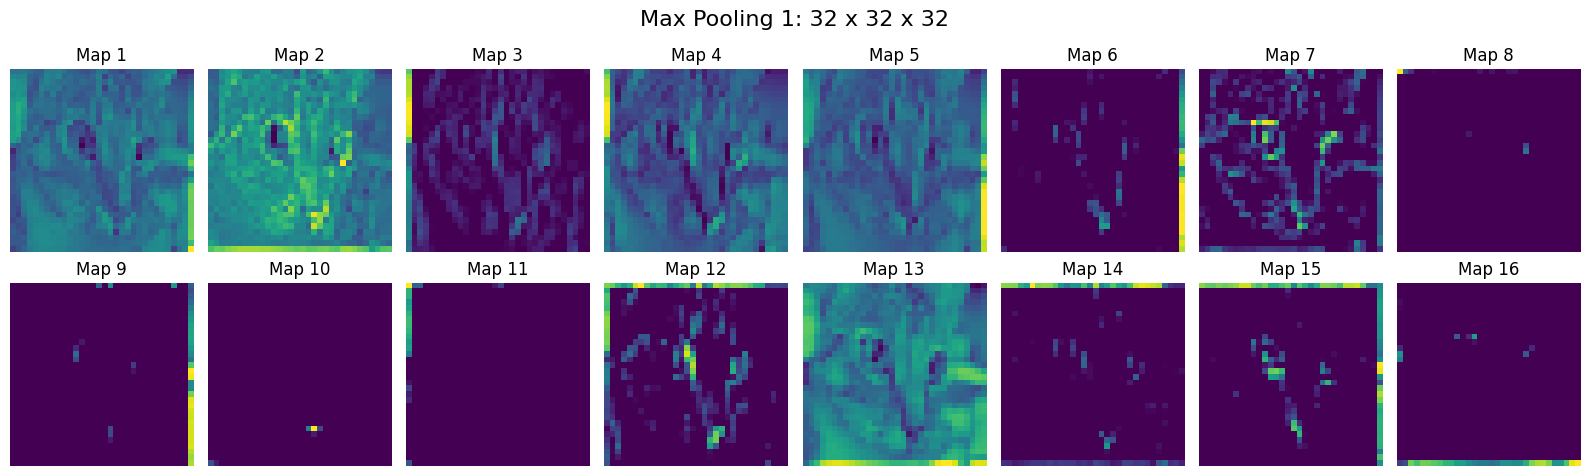

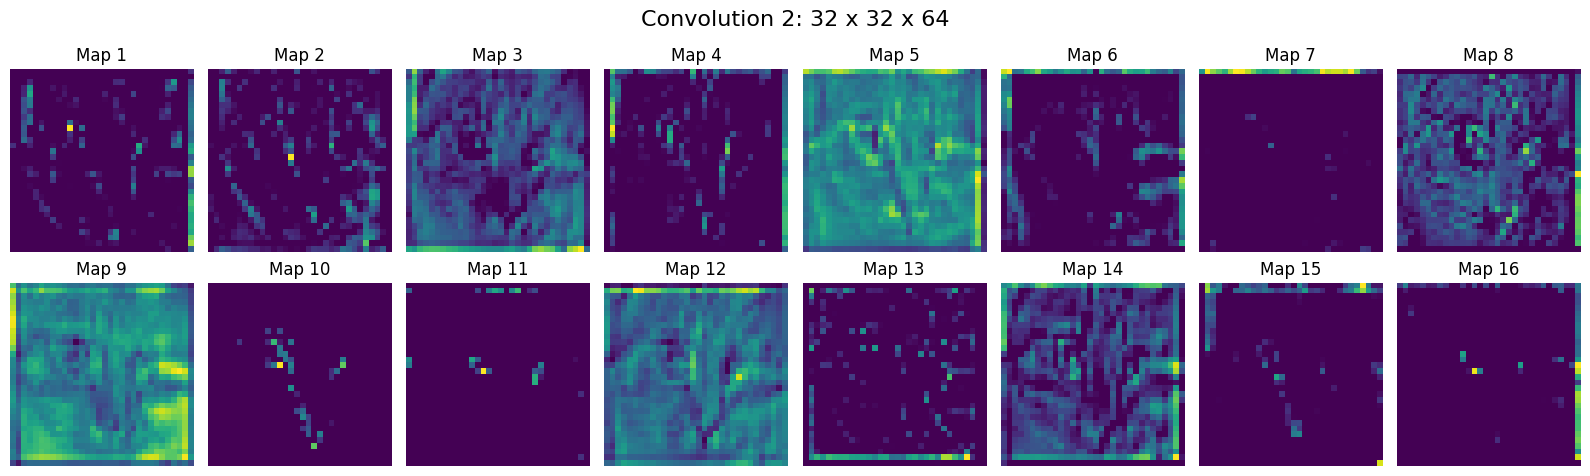

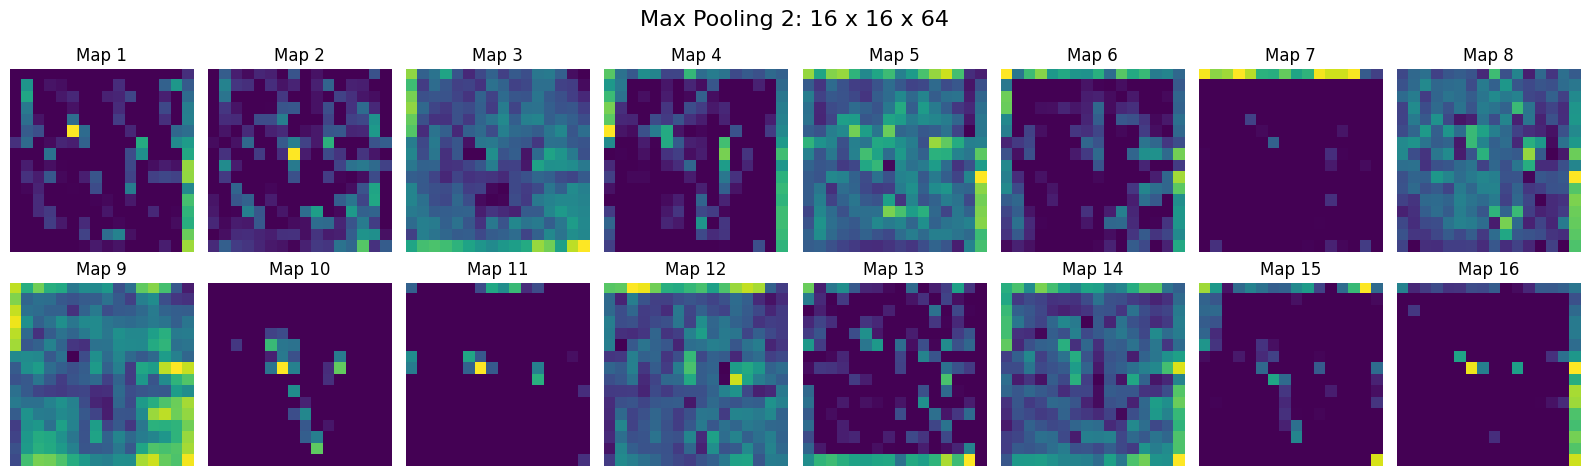

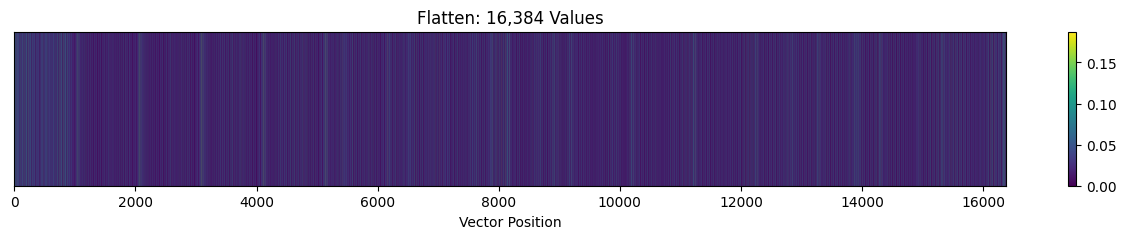

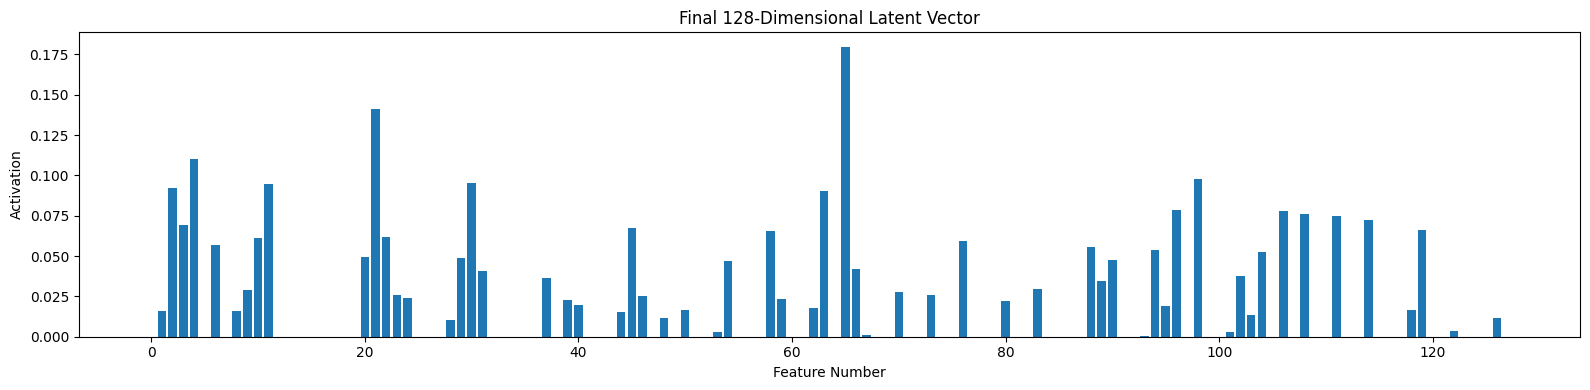


FINAL 128 FEATURES:
[0.     0.0158 0.0923 0.069  0.1104 0.     0.0567 0.     0.016  0.029
 0.0612 0.0945 0.     0.     0.     0.     0.     0.     0.     0.
 0.0497 0.1413 0.0621 0.0262 0.0238 0.     0.     0.     0.0107 0.0487
 0.0952 0.0405 0.     0.     0.     0.     0.     0.0362 0.     0.0227
 0.0195 0.     0.     0.     0.0153 0.0675 0.0251 0.     0.0115 0.
 0.0166 0.     0.     0.003  0.0467 0.     0.     0.     0.0653 0.0231
 0.     0.     0.0181 0.0901 0.     0.1797 0.0423 0.0014 0.     0.
 0.028  0.     0.     0.0262 0.     0.     0.0596 0.     0.     0.
 0.0222 0.     0.     0.0296 0.     0.     0.     0.     0.0556 0.0343
 0.0473 0.     0.     0.0004 0.054  0.0192 0.0788 0.     0.0975 0.
 0.     0.0031 0.0376 0.0137 0.0524 0.     0.078  0.     0.0761 0.
 0.     0.075  0.     0.     0.0725 0.     0.     0.     0.0168 0.0663
 0.     0.     0.0034 0.     0.     0.     0.0116 0.    ]

Saved cat_128_features.csv


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from skimage import data, transform


# 1. LOAD CAT IMAGE


tf.keras.utils.set_random_seed(42)

cat = data.chelsea()

cat = transform.resize(
    cat,
    (64, 64),
    anti_aliasing=True
).astype("float32")

image = cat[None, ...]

print("Original image:", image.shape)


# 2. BUILD CNN


inputs = tf.keras.Input(
    shape=(64, 64, 3),
    name="Input_Image"
)

x1 = tf.keras.layers.Conv2D(
    32, (3, 3),
    padding="same",
    activation="relu",
    name="Conv1"
)(inputs)

x2 = tf.keras.layers.MaxPooling2D(
    (2, 2),
    name="Pool1"
)(x1)

x3 = tf.keras.layers.Conv2D(
    64, (3, 3),
    padding="same",
    activation="relu",
    name="Conv2"
)(x2)

x4 = tf.keras.layers.MaxPooling2D(
    (2, 2),
    name="Pool2"
)(x3)

x5 = tf.keras.layers.Flatten(
    name="Flatten"
)(x4)

x6 = tf.keras.layers.Dense(
    128,
    activation="relu",
    name="Latent_128"
)(x5)

model = tf.keras.Model(
    inputs=inputs,
    outputs=x6
)

model.summary()


# 3. EXTRACT ALL INTERMEDIATE OUTPUTS


visual_model = tf.keras.Model(
    inputs=model.input,
    outputs=[
        model.get_layer("Conv1").output,
        model.get_layer("Pool1").output,
        model.get_layer("Conv2").output,
        model.get_layer("Pool2").output,
        model.get_layer("Flatten").output,
        model.get_layer("Latent_128").output
    ]
)

outputs = visual_model(
    image,
    training=False
)

conv1, pool1, conv2, pool2, flat, latent = [
    output.numpy()[0]
    for output in outputs
]


# 4. PRINT DIMENSIONS


print("\nCNN TRANSFORMATION")

print("Input:", cat.shape)
print("Conv1:", conv1.shape)
print("Pool1:", pool1.shape)
print("Conv2:", conv2.shape)
print("Pool2:", pool2.shape)
print("Flatten:", flat.shape)
print("Latent:", latent.shape)


# 5. VISUALIZATION FUNCTION


def show_maps(feature_maps, title, count=16):

    count = min(count, feature_maps.shape[-1])

    fig, axes = plt.subplots(
        2, 8,
        figsize=(16, 5)
    )

    for i, ax in enumerate(axes.flat):

        if i < count:

            ax.imshow(
                feature_maps[:, :, i],
                cmap="viridis"
            )

            ax.set_title(f"Map {i+1}")

        ax.axis("off")

    fig.suptitle(title, fontsize=16)

    plt.tight_layout()
    plt.show()



# 6. ORIGINAL RGB CHANNELS


fig, axes = plt.subplots(
    1, 4,
    figsize=(14, 4)
)

axes[0].imshow(cat)
axes[0].set_title("Original Cat")

for i, name in enumerate(
    ["Red", "Green", "Blue"]
):

    axes[i+1].imshow(
        cat[:, :, i],
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[i+1].set_title(name)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


# 7. CONVOLUTION 1


show_maps(
    conv1,
    "Convolution 1: 64 x 64 x 32"
)


# 8. MAX POOLING 1


show_maps(
    pool1,
    "Max Pooling 1: 32 x 32 x 32"
)


# 9. CONVOLUTION 2


show_maps(
    conv2,
    "Convolution 2: 32 x 32 x 64"
)


# 10. MAX POOLING 2


show_maps(
    pool2,
    "Max Pooling 2: 16 x 16 x 64"
)


# 11. FLATTEN VISUALIZATION


plt.figure(figsize=(16, 2))

plt.imshow(
    flat.reshape(1, -1),
    aspect="auto",
    cmap="viridis"
)

plt.title(
    "Flatten: 16,384 Values"
)

plt.yticks([])
plt.xlabel("Vector Position")
plt.colorbar()
plt.show()


# 12. FINAL 128 FEATURES


plt.figure(figsize=(16, 4))

plt.bar(
    np.arange(128),
    latent
)

plt.title(
    "Final 128-Dimensional Latent Vector"
)

plt.xlabel("Feature Number")
plt.ylabel("Activation")

plt.tight_layout()
plt.show()

print("\nFINAL 128 FEATURES:")
print(np.round(latent, 4))


# 13. SAVE LATENT VECTOR


np.savetxt(
    "cat_128_features.csv",
    latent.reshape(1, -1),
    delimiter=","
)

print("\nSaved cat_128_features.csv")